In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [2]:
df = pd.read_csv("cleaned_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8790, 16)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month,added_day,duration_value,duration_type,primary_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,25,90,min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure",2021,9,24,1,Seasons,Crime TV Shows
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,24,1,Seasons,TV Dramas
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,22,91,min,Children & Family Movies
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,24,125,min,Dramas


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   show_id         8790 non-null   str  
 1   type            8790 non-null   str  
 2   title           8790 non-null   str  
 3   director        8790 non-null   str  
 4   country         8790 non-null   str  
 5   date_added      8790 non-null   str  
 6   release_year    8790 non-null   int64
 7   rating          8790 non-null   str  
 8   duration        8790 non-null   str  
 9   listed_in       8790 non-null   str  
 10  added_year      8790 non-null   int64
 11  added_month     8790 non-null   int64
 12  added_day       8790 non-null   int64
 13  duration_value  8790 non-null   int64
 14  duration_type   8790 non-null   str  
 15  primary_genre   8790 non-null   str  
dtypes: int64(5), str(11)
memory usage: 1.1 MB


# Movies vs TV Shows

In [4]:
type_counts = df["type"].value_counts()
print(type_counts)

type_percentage = df["type"].value_counts(normalize=True) * 100
print(type_percentage.round(2))

type
Movie      6126
TV Show    2664
Name: count, dtype: int64
type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


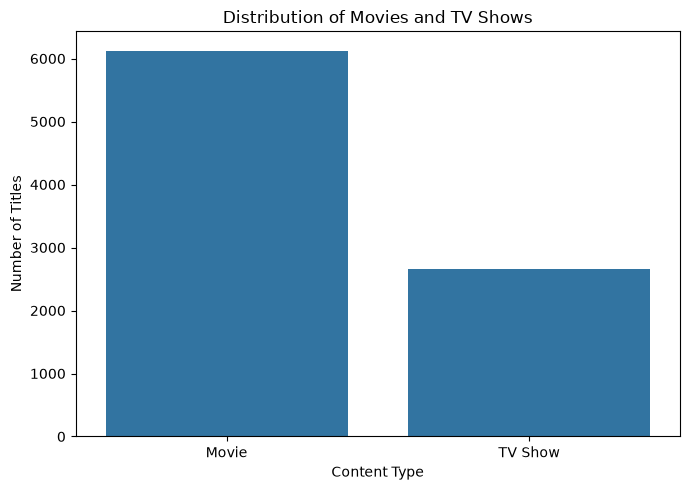

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="type")

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

# Content Added Over the Years

In [6]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
print(df["date_added"].dtypes)

datetime64[us]


In [7]:
yearly_additions = df["date_added"].dt.year.value_counts().sort_index()
print(yearly_additions)

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


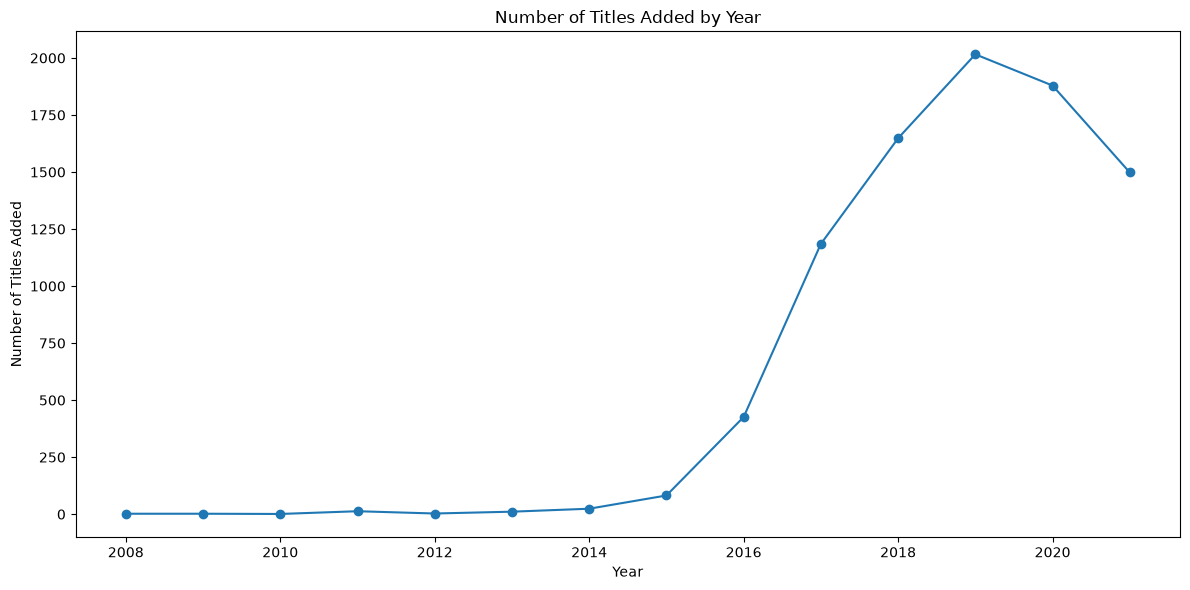

In [8]:
plt.figure(figsize=(12, 6))

yearly_additions.plot(kind="line", marker="o")

plt.title("Number of Titles Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.tight_layout()
plt.show()

# Top Countries

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64


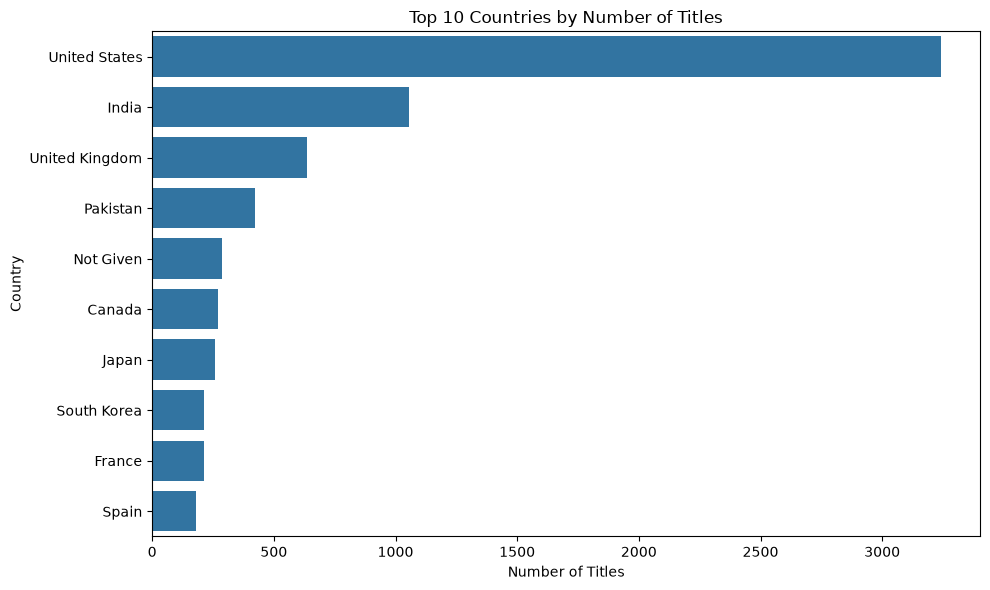

In [9]:
top_countries = df["country"].value_counts().head(10)
print(top_countries)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Top Genres

In [10]:
top_genres = df["primary_genre"].value_counts().head(10)
print(top_genres)

primary_genre
Dramas                      1599
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


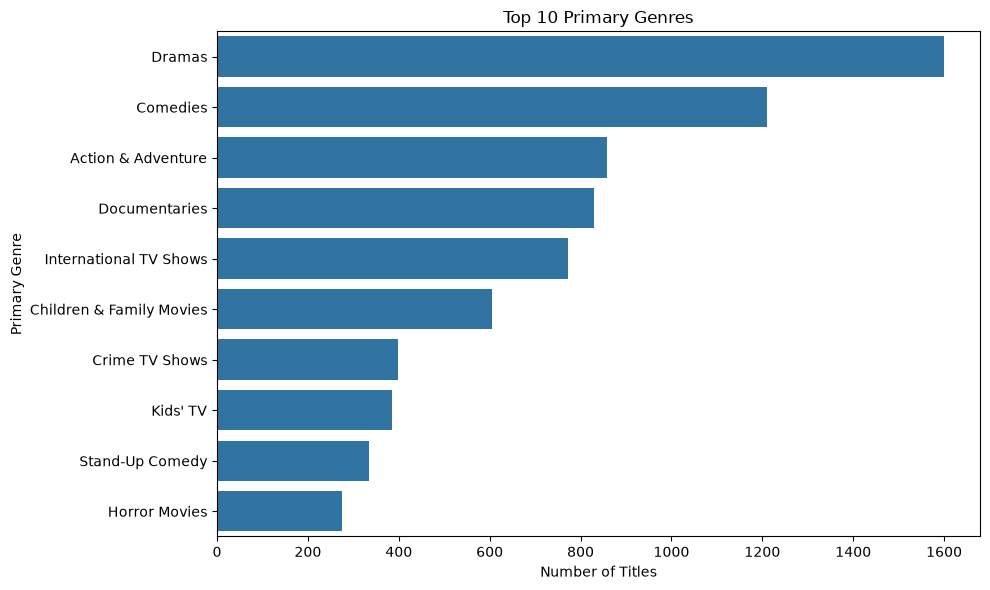

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Primary Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Primary Genre")
plt.tight_layout()
plt.show()

# Ratings Distribution

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


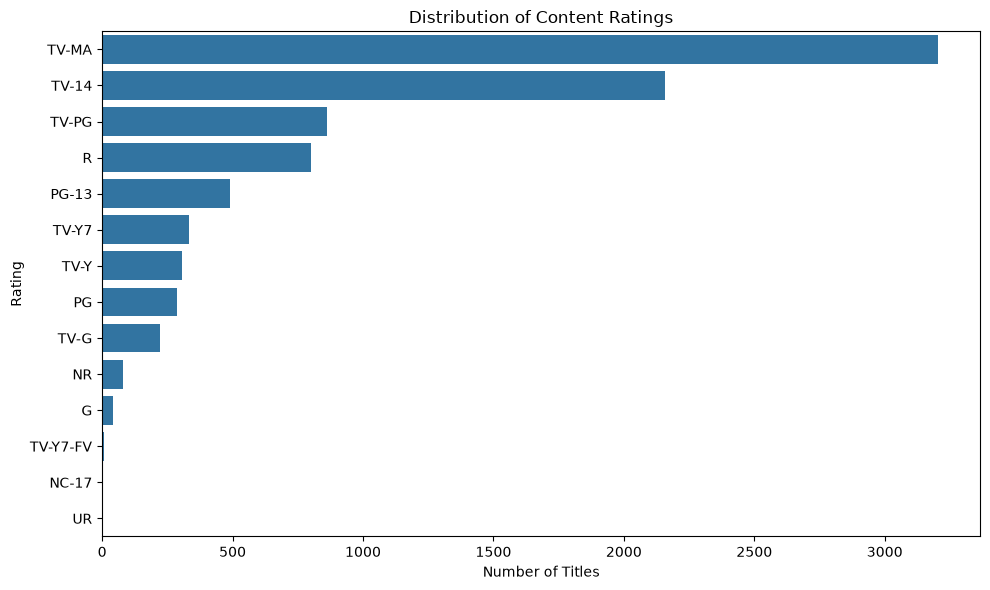

In [12]:
rating_counts = df["rating"].value_counts()
print(rating_counts)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title("Distribution of Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# Movie Duration Analysis

In [13]:
movie_duration = df[df["duration_type"] == "min"]["duration_value"]

print("Number of Movies:", len(movie_duration))
print("Average Movie Duration:", round(movie_duration.mean(), 2), "minutes")
print("Minimum Movie Duration:", movie_duration.min(), "minutes")
print("Maximum Movie Duration:", movie_duration.max(), "minutes")

Number of Movies: 6126
Average Movie Duration: 99.58 minutes
Minimum Movie Duration: 3 minutes
Maximum Movie Duration: 312 minutes


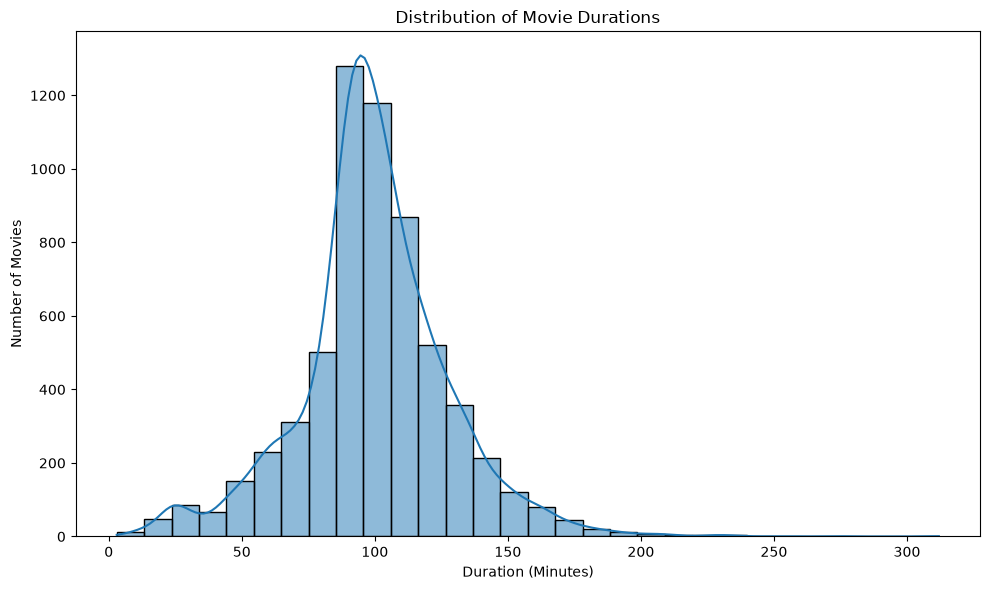

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(movie_duration, bins=30, kde=True)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

# TV Show Seasons Analysis

In [15]:
tv_seasons = df[df["duration_type"] == "Seasons"]["duration_value"]

print("Number of TV Shows:", len(tv_seasons))
print("Average Number of Seasons:", round(tv_seasons.mean(), 2))
print("Minimum Seasons:", tv_seasons.min())
print("Maximum Seasons:", tv_seasons.max())

Number of TV Shows: 2664
Average Number of Seasons: 1.75
Minimum Seasons: 1
Maximum Seasons: 17


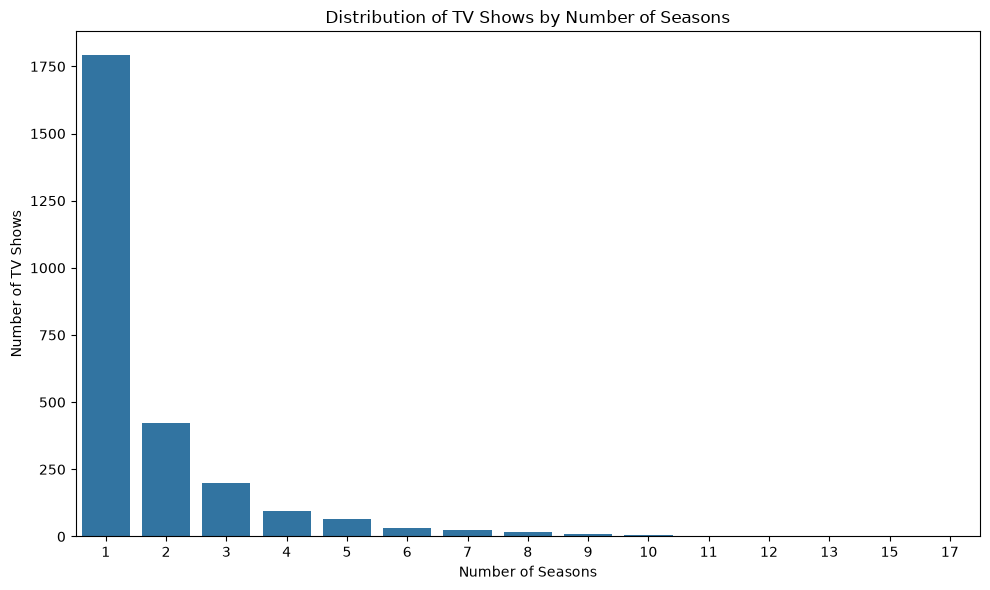

In [16]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x=tv_seasons,
    order=sorted(tv_seasons.unique())
)

plt.title("Distribution of TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.tight_layout()
plt.show()

In [17]:
season_counts = tv_seasons.value_counts().sort_index()
print(season_counts)

duration_value
1     1791
2      421
3      198
4       94
5       64
6       33
7       23
8       17
9        9
10       6
11       1
12       2
13       2
15       2
17       1
Name: count, dtype: int64


# Movies vs TV Shows by Year

In [18]:
year_type = (
    df.groupby(["added_year", "type"])
    .size()
    .unstack(fill_value=0)
)

print(year_type)

type        Movie  TV Show
added_year                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          251      175
2017          836      349
2018         1237      411
2019         1424      592
2020         1284      595
2021          993      505


<Figure size 1200x600 with 0 Axes>

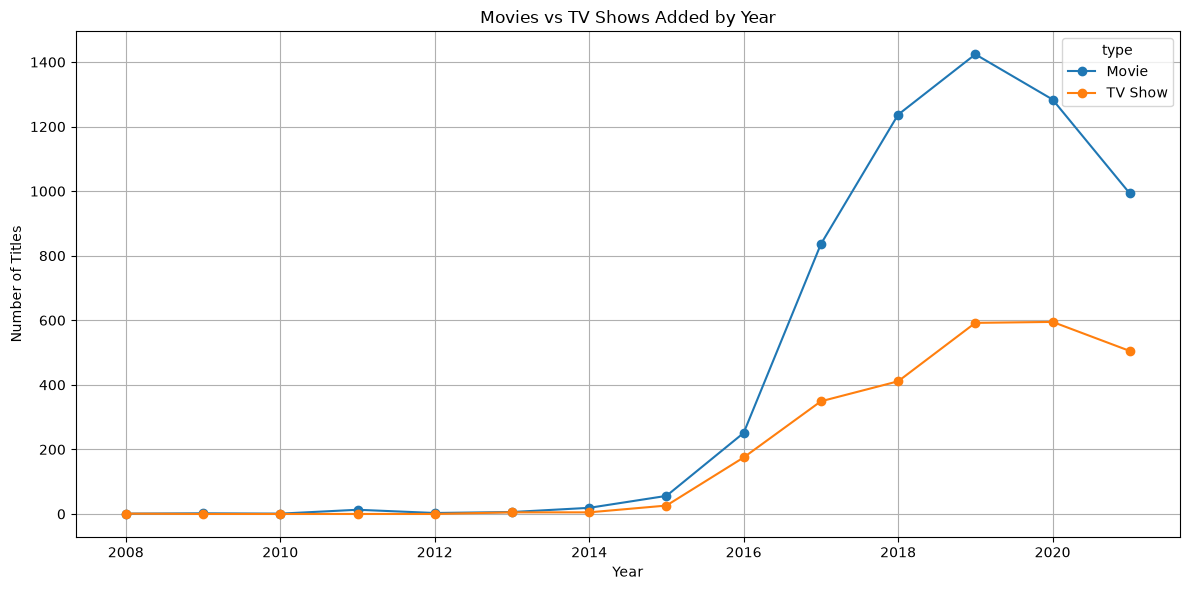

In [19]:
plt.figure(figsize=(12, 6))

year_type.plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Movies vs TV Shows Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.tight_layout()
plt.show()

# Monthly Content Additions

In [20]:
monthly_additions = df["added_month"].value_counts().sort_index()
print(monthly_additions)

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_additions.index = monthly_additions.index.map(month_names)

print(monthly_additions)

added_month
1     737
2     562
3     741
4     763
5     632
6     728
7     827
8     754
9     769
10    760
11    705
12    812
Name: count, dtype: int64
added_month
January      737
February     562
March        741
April        763
May          632
June         728
July         827
August       754
September    769
October      760
November     705
December     812
Name: count, dtype: int64


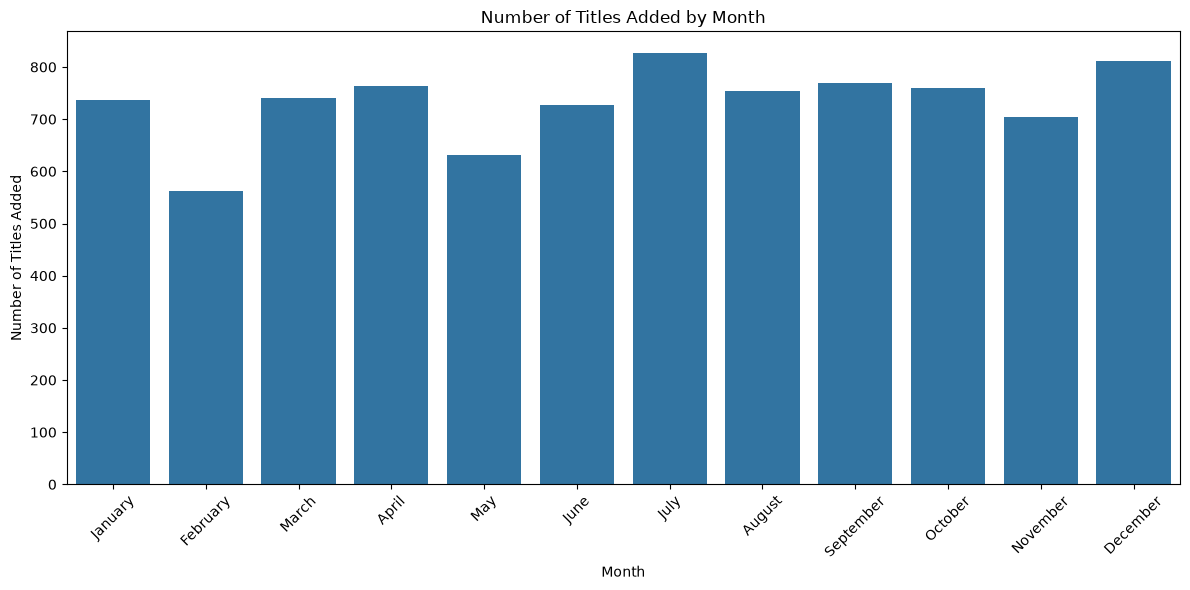

In [21]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=monthly_additions.index,
    y=monthly_additions.values
)

plt.title("Number of Titles Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Key Insights

After exploring the dataset, I found the following observations:

1. The dataset contains more Movies than TV Shows.

2. The number of titles added to the dataset increased significantly after 2016, with the highest overall additions recorded around 2019.

3. The United States has the highest number of titles associated with it, followed by India and the United Kingdom.

4. Dramas are the most common primary genre in the dataset, followed by Comedies and Action & Adventure.

5. TV-MA is the most common content rating, followed by TV-14.

6. Most movies are concentrated around the 80–120 minute duration range.

7. Most TV Shows have only 1 season. The average number of seasons among TV Shows is about 1.75.

8. Movies were added in higher numbers than TV Shows across the years in this dataset.

9. July has the highest number of recorded additions by month, while February has the lowest.

## Conclusion

This exploratory analysis helped me understand the overall structure and distribution of the Netflix titles dataset. I used different types of analysis and visualizations to identify patterns in content type, release additions, countries, genres, ratings, movie durations, and TV show seasons.

The analysis also shows that the dataset contains a much larger number of Movies than TV Shows and that most TV Shows have a relatively small number of seasons.
